# Sprint 6 — MetaGPT Team multiagente real (solo n=40 por costo real de llm) Data real 88k, data real para RAG 6K validados y etiquetados

Experimento reproducible: clasificación **play / pausa / stop** sobre BugsRepo con **MetaGPT Team real** (no solo provider LLM), pgvector y criticidad Camino B-lite.

**Protocolo:** split estratificado fijo `n=40`, `seed=42`, calibración solo train/history, mismo test para baseline / MetaGPT Team / Var1 / Var2, cache LLM, logs completos.

> LLm utilizado para todos `DEEPSEEK_API_KEY`. 

## Metodología experimental 

1. **Diseño hold-out estratificado**: reservar un conjunto de test fijo con proporciones balanceadas por clase (`play/pausa/stop`). Es el estándar más defendible cuando no hay series temporales limpias ni grupos naturales (proyectos/equipos) para split grupal.
2. **Separación estricta train vs test**: imputación, escalado (TF-IDF/SVD), recuperación pgvector, calibración de umbrales y política HITL se ajustan **solo** con history/train. El test solo recibe `transform` e inferencia.
3. **Mismo protocolo para todas las variantes**: baseline, MetaGPT Team, Var1 (+RAG) y Var2 (+criticidad) evalúan exactamente las mismas filas (`text_hash` idénticos). Sin re-muestreo entre variantes.
4. **Reproducibilidad**: semillas fijas (`seed=42`), hashes de texto, artefactos versionados (`metrics.csv`, `summary.json`, `validation_checklist.csv`), cache LLM para evitar llamadas duplicadas.
5. **Métricas múltiples**: F1-Macro (balance global), F1-STOP (clase crítica), Accuracy, Cohen's Kappa, PolicyCost (costo operacional HITL). Latencia como métrica secundaria.
6. **Comparación pareada McNemar**: al compartir el mismo test, las diferencias entre variantes se evalúan con test de McNemar (no t-test independiente). Con `n=40` el poder es limitado; reportar p-values sin sobreclaim.
7. **Limitaciones explícitas**: `n=40` es piloto/defensa exploratoria, no conclusión poblacional; MetaGPT Team aumenta costo/latencia; dependencia de API externa (DeepSeek); posible fallback a reglas/RAG si Team falla.
8. **Integridad del claim multiagente**: solo afirmar "multiagente real" si corre `metagpt.team.Team` con roles coordinados (aquí: `BugTriageAnalyst` + `BugCriticalityReviewer`), no un único prompt al provider.

## Setup y rutas

In [1]:
from pathlib import Path
import json
import pandas as pd

ROOT = Path.cwd().resolve()
for candidate in (ROOT, ROOT / 'tesis2', ROOT.parent / 'tesis2', ROOT.parent):
    marker = candidate / 'src' / 'sprint6_metagpt_multiagente_uni_experiment.py'
    if marker.exists():
        ROOT = candidate
        break

OUT_DIR = ROOT / 'docs' / 'experiments' / 'sprint6_metagpt_multiagente_uni_n40'
OUT_DIR.mkdir(parents=True, exist_ok=True)
print('ROOT =', ROOT)
print('OUT_DIR =', OUT_DIR)

ROOT = /home/jlpy/Documents/4Semestre/Proyecto de Investigacion 2/Tesis/tesis2
OUT_DIR = /home/jlpy/Documents/4Semestre/Proyecto de Investigacion 2/Tesis/tesis2/docs/experiments/sprint6_metagpt_multiagente_uni_n40


## Ejecutar experimento (n=40, seed=42)

Script: `src/sprint6_metagpt_multiagente_uni_experiment.py`

- **Baseline**: reglas reproducibles sin agente
- **MetaGPT Team**: `BugTriageAnalyst` (PM/triage) + `BugCriticalityReviewer`, DeepSeek real, sin RAG
- **Var1**: MetaGPT Team + contexto pgvector top-k (train-only)
- **Var2**: Var1 + criticidad Camino B-lite calibrada en train

Requisitos: Docker, pgvector (`127.0.0.1:5432`), `DEEPSEEK_API_KEY` en `.env`, env MetaGPT Python 3.11.

In [2]:
script = ROOT / 'src' / 'sprint6_metagpt_multiagente_uni_experiment.py'
py = ROOT / 'external' / 'criticidad_sota_env' / 'bin' / 'python'
if not py.exists():
    py = 'python3'
cmd = f'"{py}" "{script}" --target-n 40 --seed 42 --max-metagpt-rows 40'
print(cmd)
# Descomenta para ejecutar (~5-6 min MetaGPT Team batch + split):
# !{cmd}

"/home/jlpy/Documents/4Semestre/Proyecto de Investigacion 2/Tesis/tesis2/external/criticidad_sota_env/bin/python" "/home/jlpy/Documents/4Semestre/Proyecto de Investigacion 2/Tesis/tesis2/src/sprint6_metagpt_multiagente_uni_experiment.py" --target-n 40 --seed 42 --max-metagpt-rows 40


## Métricas principales

In [3]:
metrics_path = OUT_DIR / 'metrics.csv'
if metrics_path.exists():
    metrics = pd.read_csv(metrics_path)
    display(metrics)
else:
    print('Pendiente: ejecutar celda anterior para generar metrics.csv')

,Modelo,n,F1-Macro,F1-STOP,Accuracy,Kappa,PolicyCost,Lat.mean.ms,Lat.p95.ms
0,Baseline reglas reproducible sin agente,40,0.3406,0.5000,0.425,0.1221,0.2335,0.0046,0.0103
1,MetaGPT Team multiagente + DeepSeek sin RAG,40,0.6002,0.8462,0.600,0.4030,0.1465,3000.2822,3868.0360
2,Var1 MetaGPT Team + pgvector top-5,40,0.7419,0.8148,0.750,0.6244,0.1350,3304.0248,4054.0045
3,Var2 Var1 + criticidad Camino B-lite (stop_heavy),40,0.6072,0.8148,0.675,0.5080,0.1190,0.0920,0.1021


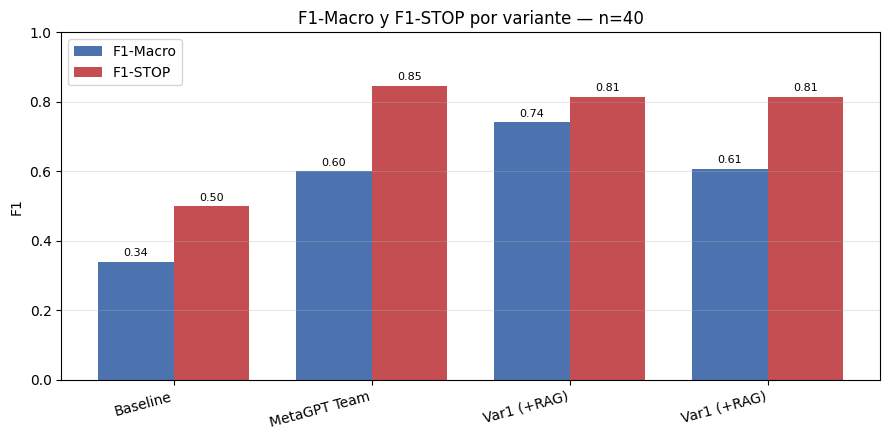

In [4]:
import matplotlib.pyplot as plt
import numpy as np


def short_label(modelo: str) -> str:
    """Etiqueta corta y legible por variante para los ejes de las gráficas."""
    m = str(modelo).lower()
    if 'baseline' in m:
        return 'Baseline'
    if 'var1' in m:
        return 'Var1 (+RAG)'
    if 'var2' in m:
        return 'Var2 (+crit)'
    if 'team' in m or 'metagpt' in m:
        return 'MetaGPT Team'
    return modelo


# Cargar métricas una vez; las celdas de gráficos siguientes reutilizan `metrics`.
metrics = pd.read_csv(metrics_path) if metrics_path.exists() else pd.DataFrame()
if not metrics.empty:
    metrics['variante'] = metrics['Modelo'].map(short_label)

# --- Figura 1: F1-Macro y F1-STOP por variante ---
if not metrics.empty and {'F1-Macro', 'F1-STOP'}.issubset(metrics.columns):
    x = np.arange(len(metrics)); w = 0.38
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.bar(x - w / 2, metrics['F1-Macro'], w, label='F1-Macro', color='#4C72B0')
    ax.bar(x + w / 2, metrics['F1-STOP'], w, label='F1-STOP', color='#C44E52')
    ax.set_xticks(x); ax.set_xticklabels(metrics['variante'], rotation=15, ha='right')
    ax.set_ylim(0, 1); ax.set_ylabel('F1')
    ax.set_title('F1-Macro y F1-STOP por variante — n=40')
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    for i, (a, b) in enumerate(zip(metrics['F1-Macro'], metrics['F1-STOP'])):
        ax.text(i - w / 2, a + 0.01, f'{a:.2f}', ha='center', va='bottom', fontsize=8)
        ax.text(i + w / 2, b + 0.01, f'{b:.2f}', ha='center', va='bottom', fontsize=8)
    plt.tight_layout(); plt.show()
else:
    print('Omitido: faltan columnas F1-Macro/F1-STOP en metrics.csv')

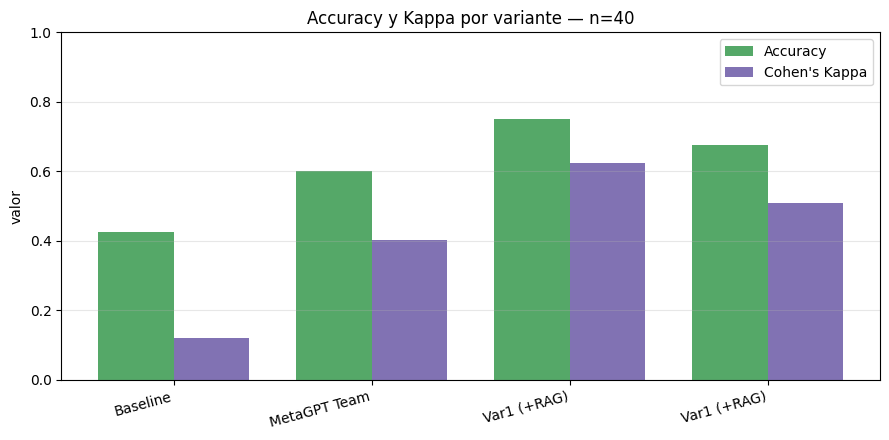

In [5]:
# --- Figura 2: Accuracy y Cohen's Kappa por variante ---
if not metrics.empty and {'Accuracy', 'Kappa'}.issubset(metrics.columns):
    x = np.arange(len(metrics)); w = 0.38
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.bar(x - w / 2, metrics['Accuracy'], w, label='Accuracy', color='#55A868')
    ax.bar(x + w / 2, metrics['Kappa'], w, label="Cohen's Kappa", color='#8172B3')
    ax.set_xticks(x); ax.set_xticklabels(metrics['variante'], rotation=15, ha='right')
    ax.set_ylim(0, 1); ax.set_ylabel('valor')
    ax.set_title('Accuracy y Kappa por variante — n=40')
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print('Omitido: faltan columnas Accuracy/Kappa en metrics.csv')

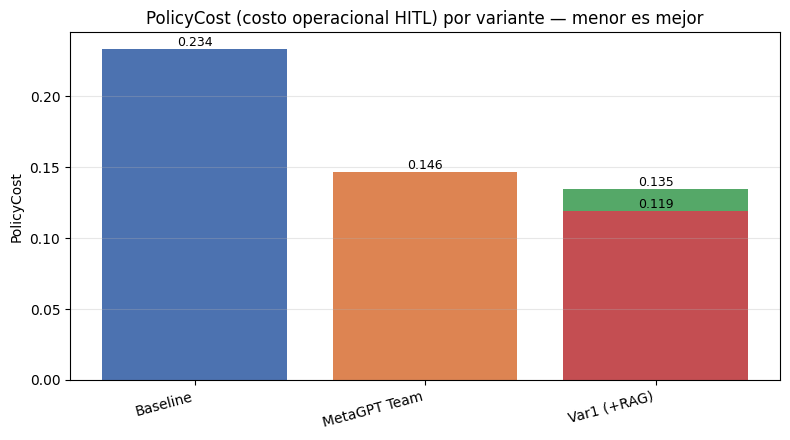

In [6]:
# --- Figura 3: PolicyCost por variante (menor = mejor) ---
if not metrics.empty and 'PolicyCost' in metrics.columns:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    bars = ax.bar(metrics['variante'], metrics['PolicyCost'],
                  color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'][:len(metrics)])
    ax.set_ylabel('PolicyCost')
    ax.set_title('PolicyCost (costo operacional HITL) por variante — menor es mejor')
    ax.grid(axis='y', alpha=0.3)
    for b, v in zip(bars, metrics['PolicyCost']):
        ax.text(b.get_x() + b.get_width() / 2, v, f'{v:.3f}',
                ha='center', va='bottom', fontsize=9)
    plt.xticks(rotation=15, ha='right'); plt.tight_layout(); plt.show()
else:
    print('Omitido: falta columna PolicyCost en metrics.csv')

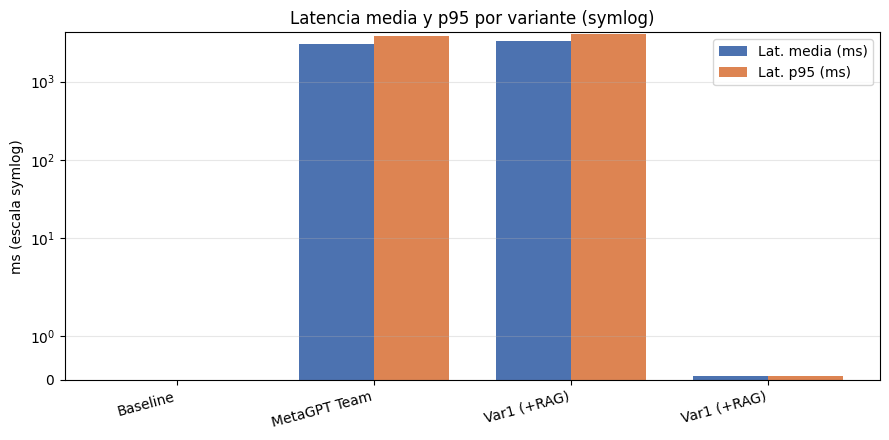

Nota: sin latencia por fila en predictions.csv -> no hay boxplot por ticket.


In [7]:
# --- Figura 4: Latencia media y p95 por variante ---
# Nota: predictions.csv NO incluye latencia por fila, así que no es posible un
# boxplot por ticket; se usan Lat.mean.ms y Lat.p95.ms de metrics.csv (escala symlog).
lat_cols = [c for c in ('Lat.mean.ms', 'Lat.p95.ms') if c in metrics.columns]
if not metrics.empty and lat_cols:
    x = np.arange(len(metrics)); w = 0.38
    fig, ax = plt.subplots(figsize=(9, 4.5))
    if 'Lat.mean.ms' in lat_cols:
        ax.bar(x - w / 2, metrics['Lat.mean.ms'], w, label='Lat. media (ms)', color='#4C72B0')
    if 'Lat.p95.ms' in lat_cols:
        ax.bar(x + w / 2, metrics['Lat.p95.ms'], w, label='Lat. p95 (ms)', color='#DD8452')
    ax.set_xticks(x); ax.set_xticklabels(metrics['variante'], rotation=15, ha='right')
    ax.set_yscale('symlog'); ax.set_ylabel('ms (escala symlog)')
    ax.set_title('Latencia media y p95 por variante (symlog)')
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()
    print('Nota: sin latencia por fila en predictions.csv -> no hay boxplot por ticket.')
else:
    print('Omitido: faltan columnas de latencia en metrics.csv')

## McNemar pareado y métricas por clase

In [8]:
for fname in ('mcnemar.csv', 'metrics_per_class.csv'):
    p = OUT_DIR / fname
    if p.exists():
        print('===', fname, '===')
        display(pd.read_csv(p))

=== mcnemar.csv ===


,Comparacion,b_A_mal_B_bien,c_A_bien_B_mal,p_value,significativo_005
0,baseline vs metagpt_team,14,7,0.189247,False
1,metagpt_team vs var1,9,3,0.145996,False
2,var1 vs var2,2,5,0.453125,False
3,baseline vs var2,10,0,0.001953,True


=== metrics_per_class.csv ===


,modelo,clase,f1,support
0,baseline,play,0.5217,14
1,baseline,pausa,0.0000,13
2,baseline,stop,0.5000,13
3,metagpt_team,play,0.4545,14
4,metagpt_team,pausa,0.5000,13
5,metagpt_team,stop,0.8462,13
6,var1,play,0.8276,14
7,var1,pausa,0.5833,13
8,var1,stop,0.8148,13
9,var2,play,0.7568,14


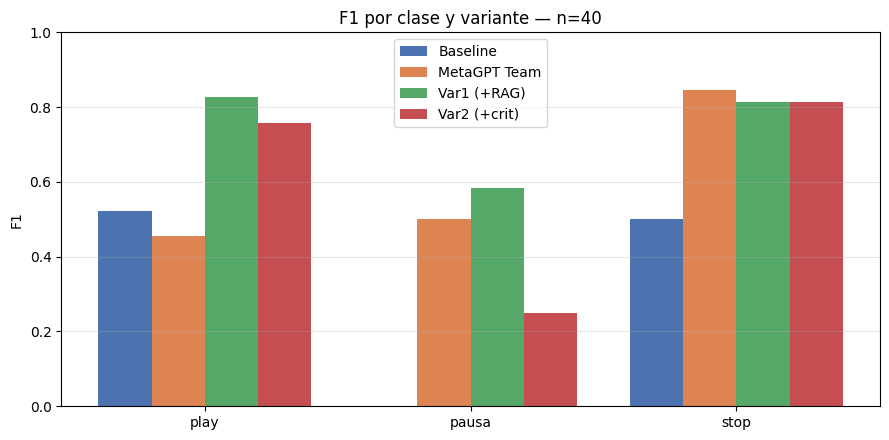

In [9]:
# --- Figura 5: F1 por clase (play/pausa/stop) agrupado por variante ---
pc_path = OUT_DIR / 'metrics_per_class.csv'
label_map = {'baseline': 'Baseline', 'metagpt_team': 'MetaGPT Team',
             'var1': 'Var1 (+RAG)', 'var2': 'Var2 (+crit)'}
PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
if pc_path.exists():
    pc = pd.read_csv(pc_path)
    pivot = pc.pivot(index='clase', columns='modelo', values='f1')
    order_cls = [c for c in ['play', 'pausa', 'stop'] if c in pivot.index]
    pivot = pivot.reindex(order_cls)
    cols = [c for c in ['baseline', 'metagpt_team', 'var1', 'var2'] if c in pivot.columns]
    pivot = pivot[cols]
    x = np.arange(len(pivot.index)); n = len(cols); w = 0.8 / max(n, 1)
    fig, ax = plt.subplots(figsize=(9, 4.5))
    for i, c in enumerate(cols):
        ax.bar(x + (i - (n - 1) / 2) * w, pivot[c], w,
               label=label_map.get(c, c), color=PALETTE[i % len(PALETTE)])
    ax.set_xticks(x); ax.set_xticklabels(pivot.index)
    ax.set_ylim(0, 1); ax.set_ylabel('F1')
    ax.set_title('F1 por clase y variante — n=40')
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print('Omitido: no existe metrics_per_class.csv')

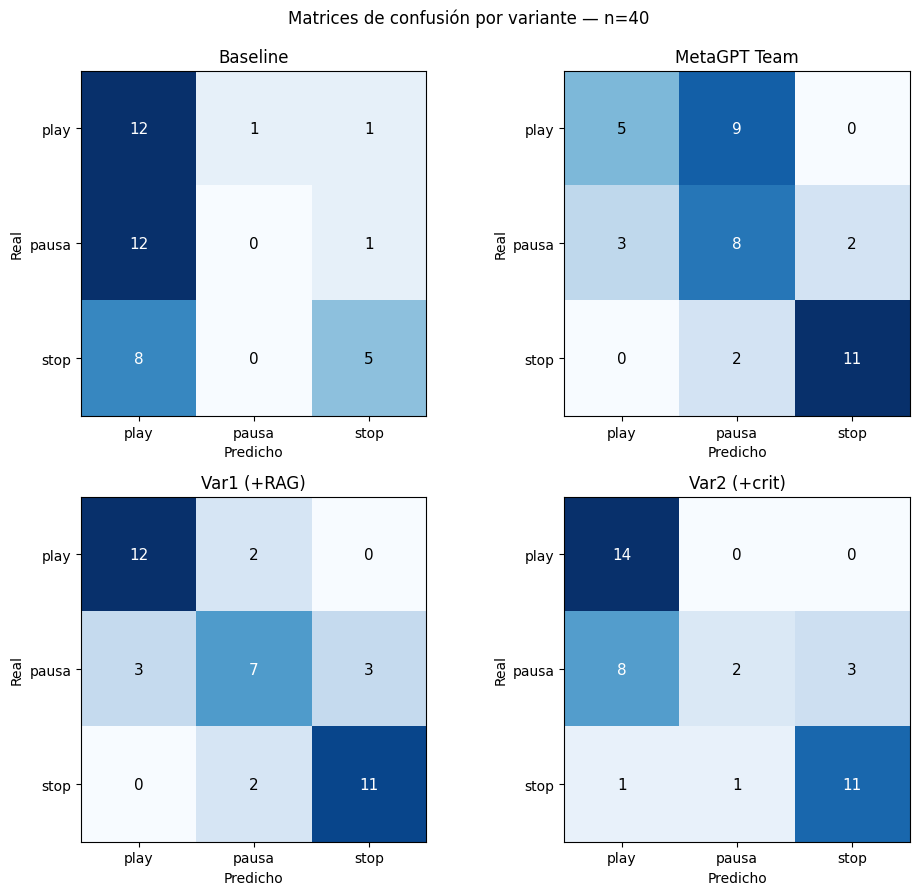

In [10]:
# --- Figura 6: Matrices de confusión por variante (panel 2x2) ---
preds_path = OUT_DIR / 'predictions.csv'
pred_cols = {'baseline': 'pred_baseline', 'metagpt_team': 'pred_metagpt_team',
             'var1': 'pred_var1', 'var2': 'pred_var2'}
if preds_path.exists():
    preds = pd.read_csv(preds_path)
    classes = ['play', 'pausa', 'stop']
    avail = [(k, v) for k, v in pred_cols.items()
             if v in preds.columns and 'thesis_class' in preds.columns]
    if avail:
        fig, axes = plt.subplots(2, 2, figsize=(10, 9))
        axes = axes.ravel()
        for ax, (key, col) in zip(axes, avail):
            cm = pd.crosstab(preds['thesis_class'], preds[col]).reindex(
                index=classes, columns=classes, fill_value=0)
            ax.imshow(cm.values, cmap='Blues')
            ax.set_xticks(range(len(classes))); ax.set_xticklabels(classes)
            ax.set_yticks(range(len(classes))); ax.set_yticklabels(classes)
            ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
            ax.set_title(label_map.get(key, key))
            vmax = cm.values.max()
            for i in range(len(classes)):
                for j in range(len(classes)):
                    v = cm.values[i, j]
                    ax.text(j, i, str(v), ha='center', va='center',
                            color='white' if v > vmax / 2 else 'black', fontsize=11)
        for ax in axes[len(avail):]:
            ax.axis('off')
        fig.suptitle('Matrices de confusión por variante — n=40', y=0.99)
        plt.tight_layout(); plt.show()
    else:
        print('Omitido: faltan columnas pred_* o thesis_class en predictions.csv')
else:
    print('Omitido: no existe predictions.csv')

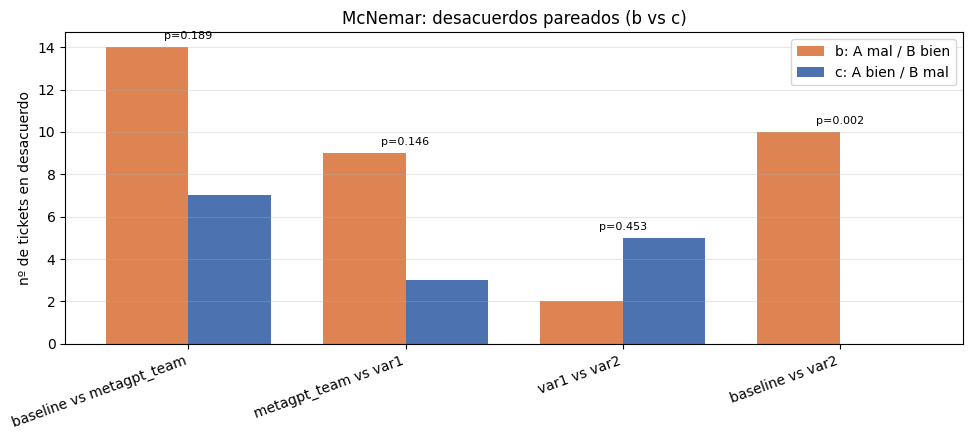

In [11]:
# --- Figura 7: McNemar — desacuerdos pareados (b vs c) por comparación ---
mc_path = OUT_DIR / 'mcnemar.csv'
if mc_path.exists():
    mc = pd.read_csv(mc_path)
    bcol, ccol = 'b_A_mal_B_bien', 'c_A_bien_B_mal'
    if {bcol, ccol, 'Comparacion'}.issubset(mc.columns):
        x = np.arange(len(mc)); w = 0.38
        fig, ax = plt.subplots(figsize=(10, 4.5))
        ax.bar(x - w / 2, mc[bcol], w, label='b: A mal / B bien', color='#DD8452')
        ax.bar(x + w / 2, mc[ccol], w, label='c: A bien / B mal', color='#4C72B0')
        ax.set_xticks(x); ax.set_xticklabels(mc['Comparacion'], rotation=20, ha='right')
        ax.set_ylabel('nº de tickets en desacuerdo')
        ax.set_title('McNemar: desacuerdos pareados (b vs c)')
        ax.legend(); ax.grid(axis='y', alpha=0.3)
        if 'p_value' in mc.columns:
            for i, p in enumerate(mc['p_value']):
                top = max(mc[bcol].iloc[i], mc[ccol].iloc[i])
                ax.text(i, top + 0.3, f'p={p:.3f}', ha='center', va='bottom', fontsize=8)
        plt.tight_layout(); plt.show()
    else:
        print('Omitido: faltan columnas b/c en mcnemar.csv')
else:
    print('Omitido: no existe mcnemar.csv')

## Checklist Sprint 2

In [12]:
checklist_path = OUT_DIR / 'validation_checklist.csv'
if checklist_path.exists():
    checklist = pd.read_csv(checklist_path)
    display(checklist)
    print('\nResumen:', checklist['estado'].value_counts().to_dict())
else:
    print('Pendiente: validation_checklist.csv')

,item,estado,evidencia
0,Split test fijo estratificado,OK,n_eval=40; seed=42; play/pausa/stop
1,Sin overlap train/test (hash),OK,eval_history_hash_overlap=0
2,Fit embeddings solo train/history,OK,TF-IDF+SVD fit en retrieval_train/history; tes...
3,Calibracion solo train/history,OK,calibration_n=600; eval_calibration_hash_overl...
4,Misma data test para variantes,OK,mismos 40 text_hash baseline/metagpt/var1/var2
5,Seeds fijadas protocolo Semana 5,OK,seed=42; RANDOM_SEED compartido bugsrepo_loader
6,Sin cambios data entre baseline y eval final,OK,test fijo por hash; calibracion train-only ant...
7,pgvector real,OK,pgvector SQL disponible (extension 0.8.2)
8,MetaGPT Team multiagente real,OK,Team real: BugTriageAnalyst (PM/triage) + BugC...
9,Probe Team pre-batch,OK,"{""ok"": true, ""reason"": null, ""returncode"": 0}"



Resumen: {'OK': 12}


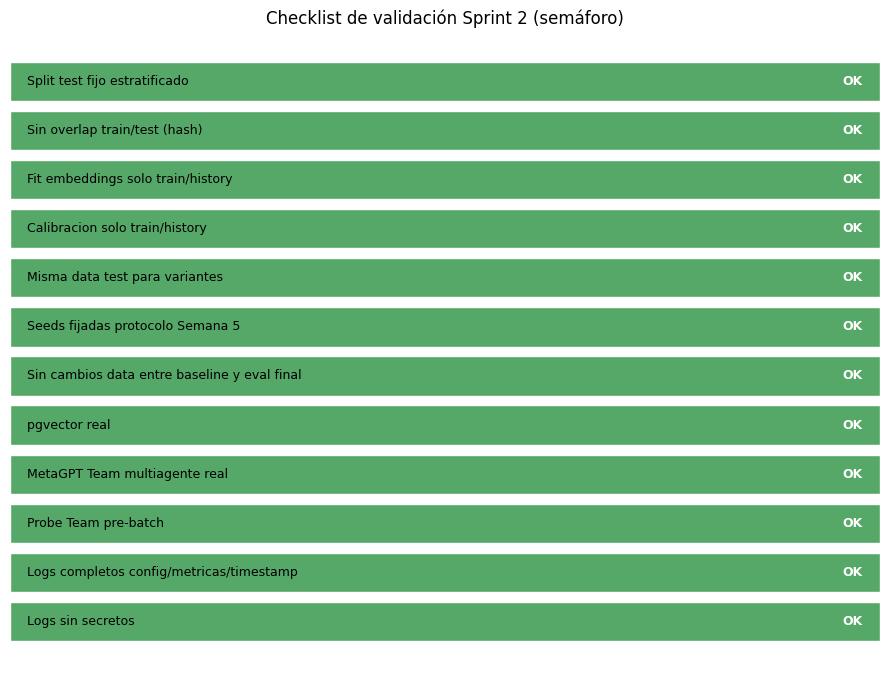

Resumen estados: {'OK': 12}


In [13]:
# --- Figura 8: Checklist Sprint 2 (semáforo) ---
import matplotlib.pyplot as plt
import numpy as np

chk_path = OUT_DIR / 'validation_checklist.csv'
if chk_path.exists():
    chk = pd.read_csv(chk_path)
    color_map = {'OK': '#55A868', 'WARN': '#DDB452', 'WARNING': '#DDB452',
                 'FAIL': '#C44E52', 'ERROR': '#C44E52', 'PARCIAL': '#DDB452'}
    colors = [color_map.get(str(e).upper(), '#999999') for e in chk['estado']]
    fig, ax = plt.subplots(figsize=(9, 0.45 * len(chk) + 1.5))
    y = np.arange(len(chk))[::-1]
    ax.barh(y, [1] * len(chk), color=colors, edgecolor='white')
    for yi, item, est in zip(y, chk['item'], chk['estado']):
        ax.text(0.02, yi, str(item), va='center', ha='left', fontsize=9, color='black')
        ax.text(0.98, yi, str(est), va='center', ha='right', fontsize=9,
                fontweight='bold', color='white')
    ax.set_xlim(0, 1); ax.set_yticks([]); ax.set_xticks([])
    ax.set_title('Checklist de validación Sprint 2 (semáforo)')
    for s in ax.spines.values():
        s.set_visible(False)
    plt.tight_layout(); plt.show()
    print('Resumen estados:', chk['estado'].value_counts().to_dict())
else:
    print('Omitido: no existe validation_checklist.csv')

## Análisis doble pasada

### Pasada exploratoria (corrida final n=40)

| Modelo | F1-Macro | F1-STOP | Accuracy | PolicyCost | Lat.mean.ms |
|--------|----------|---------|----------|------------|-------------|
| Baseline reglas | 0.3406 | 0.5000 | 0.425 | 0.2335 | ~0 |
| MetaGPT Team sin RAG | 0.6002 | 0.8462 | 0.600 | 0.1465 | ~3000 |
| Var1 Team + pgvector | **0.7419** | 0.8148 | **0.750** | 0.1350 | ~3300 |
| Var2 + criticidad | 0.6072 | 0.8148 | 0.675 | **0.1190** | ~0.09 |

- **Var1** lidera F1-Macro y Accuracy: el contexto pgvector train-only aporta señal clara sobre Team solo.
- **MetaGPT Team** (80/80 ok) supera baseline en Macro-F1 (+0.26) y F1-STOP (+0.35).
- **Var2 stop_heavy** reduce PolicyCost vs Var1 pero pierde Macro-F1 (0.6072 vs 0.7419).
- McNemar: baseline vs Var2 significativo (p=0.002); var1 vs var2 no (p=0.45).

### Pasada crítica

- `n=40` limita poder; metagpt vs var1 (9 vs 3) no alcanza significancia (p=0.15).
- Latencia Team ~3 s/ticket vs Var2 <1 ms — costo operacional real.
- Var2 no debe presentarse como ganador global de clasificación; aporta capa HITL/coste.
- MetaGPT Team **real** verificado en checklist (no provider-only): roles `BugTriageAnalyst` + `BugCriticalityReviewer`, `eval_history_hash_overlap=0`.

In [14]:
summary_path = OUT_DIR / 'summary.json'
if summary_path.exists():
    summary = json.loads(summary_path.read_text(encoding='utf-8'))
    print('timestamp_utc:', summary.get('timestamp_utc'))
    print('n_eval:', summary.get('n_eval'))
    print('metagpt_mode:', summary.get('metagpt_team', {}).get('metagpt_mode'))
    print('eval_history_hash_overlap:', summary.get('split_report', {}).get('eval_history_hash_overlap'))
    for row in summary.get('metrics', []):
        print(f"  {row['Modelo']}: F1-Macro={row['F1-Macro']} F1-STOP={row['F1-STOP']} PolicyCost={row['PolicyCost']}")
else:
    print('Ejecutar experimento para generar summary.json')

timestamp_utc: 2026-05-30T01:31:14.720996+00:00
n_eval: 40
metagpt_mode: team_multiagente
eval_history_hash_overlap: 0
  Baseline reglas reproducible sin agente: F1-Macro=0.3406 F1-STOP=0.5 PolicyCost=0.2335
  MetaGPT Team multiagente + DeepSeek sin RAG: F1-Macro=0.6002 F1-STOP=0.8462 PolicyCost=0.1465
  Var1 MetaGPT Team + pgvector top-5: F1-Macro=0.7419 F1-STOP=0.8148 PolicyCost=0.135
  Var2 Var1 + criticidad Camino B-lite (stop_heavy): F1-Macro=0.6072 F1-STOP=0.8148 PolicyCost=0.119
